In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

Loading dataset

In [7]:
df = pd.read_csv("Titanic-Dataset.csv")

sns.set_style("whitegrid")

Task 1

Age Mean: 29.69911764705882
Age Median: 28.0
Age Mode: 24.0


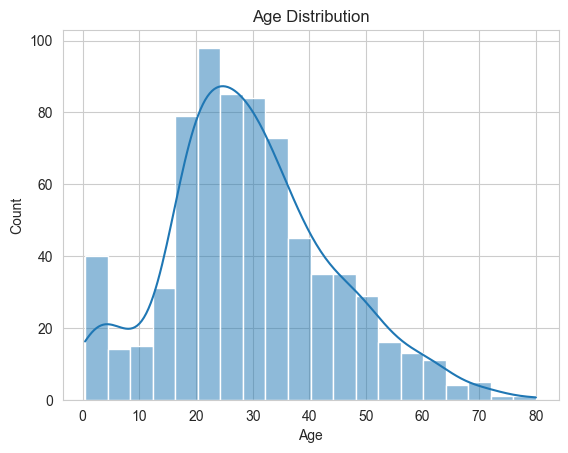

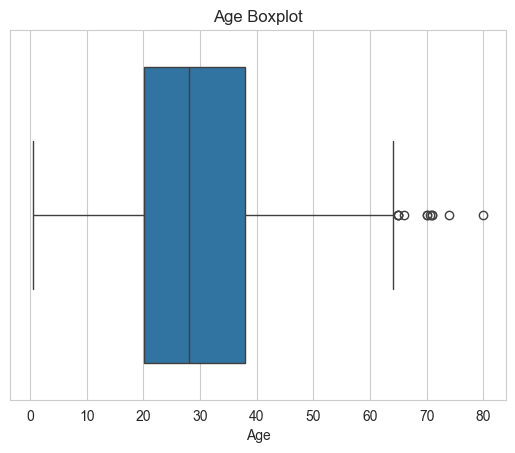

In [8]:
print("Age Mean:", df['Age'].mean())
print("Age Median:", df['Age'].median())
print("Age Mode:", df['Age'].mode()[0])

plt.figure()
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure()
sns.boxplot(x=df['Age'])
plt.title("Age Boxplot")
plt.show()

Task 2

Fare Mean: 32.204207968574636
Fare Median: 14.4542
Fare Std: 49.6934285971809


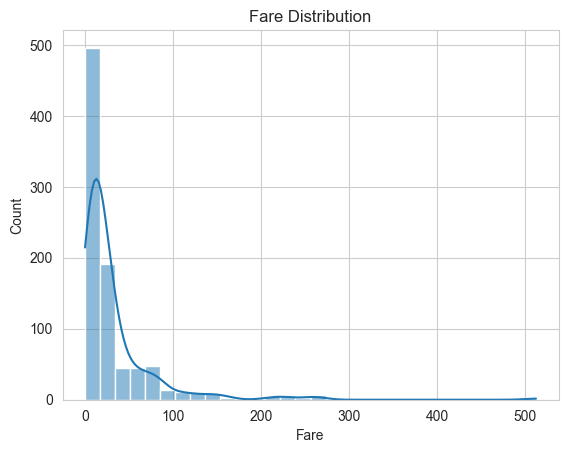

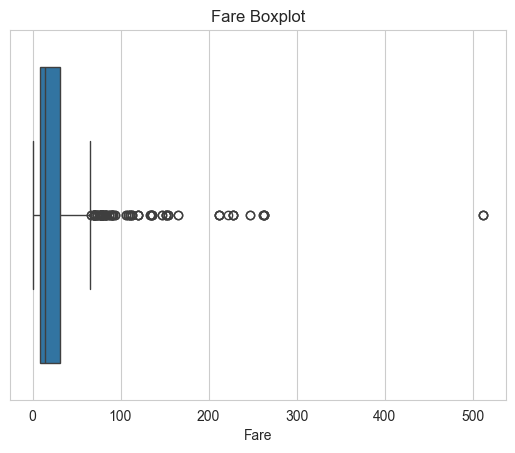

In [9]:
print("Fare Mean:", df['Fare'].mean())
print("Fare Median:", df['Fare'].median())
print("Fare Std:", df['Fare'].std())

plt.figure()
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

plt.figure()
sns.boxplot(x=df['Fare'])
plt.title("Fare Boxplot")
plt.show()

Task 3

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


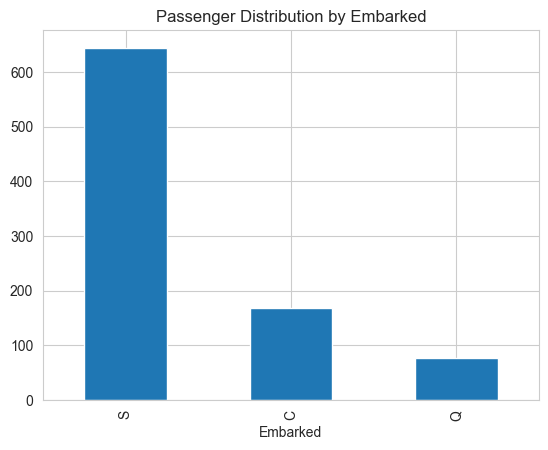

In [10]:
print(df['Embarked'].value_counts())

plt.figure()
df['Embarked'].value_counts().plot(kind='bar')
plt.title("Passenger Distribution by Embarked")
plt.show()

Task 4

Missing Age Before: 177
Missing Age After: 177


C:\Users\Youshaa Rahim\AppData\Local\Temp\ipykernel_11312\2560633296.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)


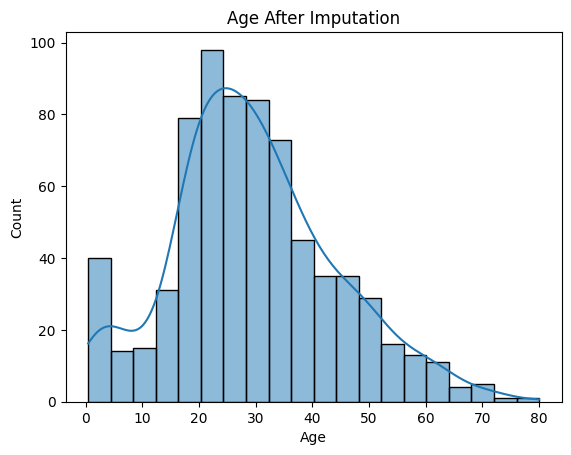

In [6]:
print("Missing Age Before:", df['Age'].isnull().sum())

df['Age'].fillna(df['Age'].median(), inplace=True)

print("Missing Age After:", df['Age'].isnull().sum())

plt.figure()
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age After Imputation")
plt.show()


Task 5

In [11]:
cabin_missing = df['Cabin'].isnull().sum()
cabin_percent = (cabin_missing / len(df)) * 100

print("Cabin Missing %:", cabin_percent)

# Usually drop due to high missing %
if cabin_percent > 50:
    df.drop(columns=['Cabin'], inplace=True)
    print("Cabin column dropped.")

Cabin Missing %: 77.10437710437711
Cabin column dropped.


Task 6

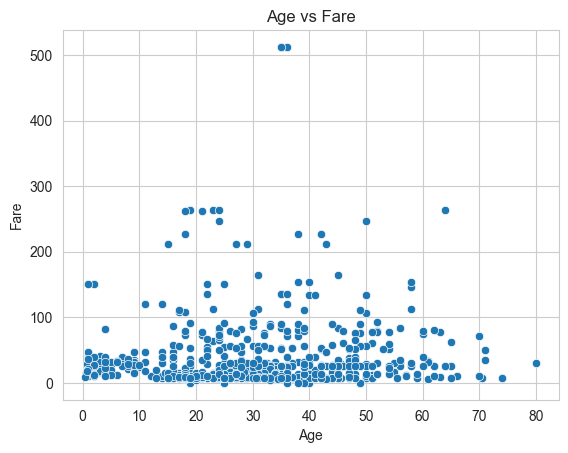

Correlation between Age and Fare:
           Age      Fare
Age   1.000000  0.096067
Fare  0.096067  1.000000


In [12]:
plt.figure()
sns.scatterplot(x='Age', y='Fare', data=df)
plt.title("Age vs Fare")
plt.show()

corr = df[['Age', 'Fare']].corr()
print("Correlation between Age and Fare:")
print(corr)

Task 7

Survived    0    1
Sex               
female     81  233
male      468  109


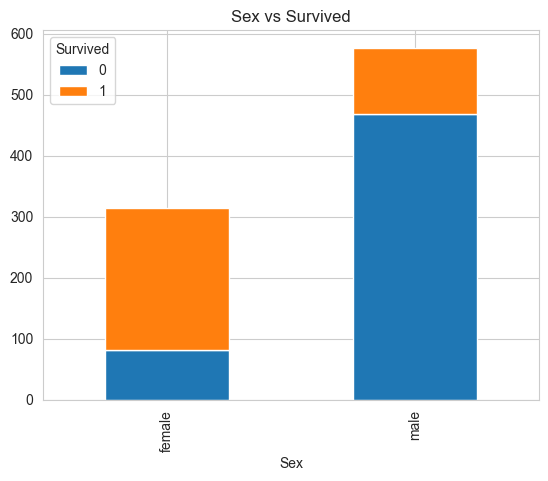

In [13]:
ct = pd.crosstab(df['Sex'], df['Survived'])
print(ct)

ct.plot(kind='bar', stacked=True)
plt.title("Sex vs Survived")
plt.show()

Task 8

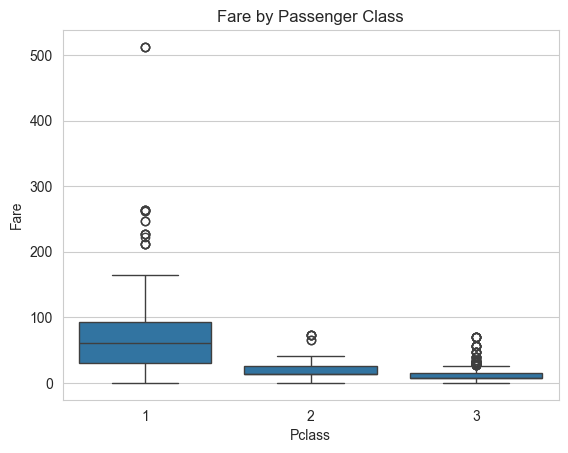

In [14]:
plt.figure()
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title("Fare by Passenger Class")
plt.show()

Task 9

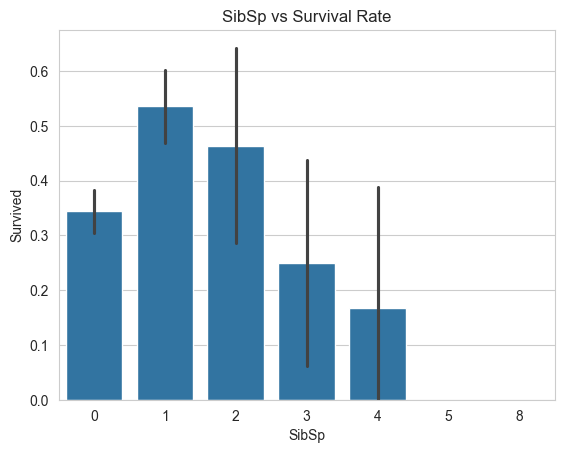

In [15]:
sns.barplot(x='SibSp', y='Survived', data=df)
plt.title("SibSp vs Survival Rate")
plt.show()

Task 10

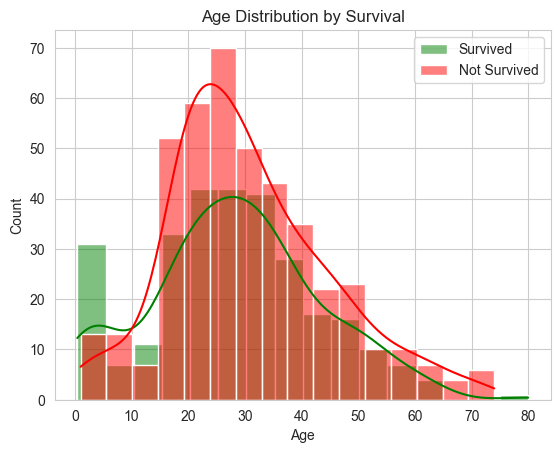

Survivor Age Mean: 28.343689655172415
Non-Survivor Age Mean: 30.62617924528302


In [16]:
plt.figure()
sns.histplot(df[df['Survived']==1]['Age'], color='green', label='Survived', kde=True)
sns.histplot(df[df['Survived']==0]['Age'], color='red', label='Not Survived', kde=True)
plt.legend()
plt.title("Age Distribution by Survival")
plt.show()

print("Survivor Age Mean:", df[df['Survived']==1]['Age'].mean())
print("Non-Survivor Age Mean:", df[df['Survived']==0]['Age'].mean())

Task 11

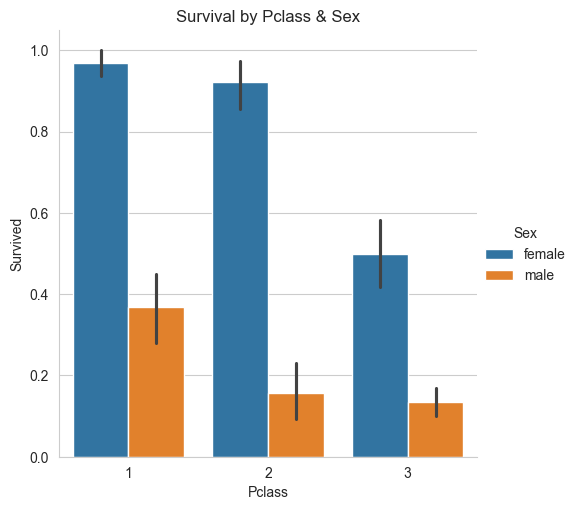

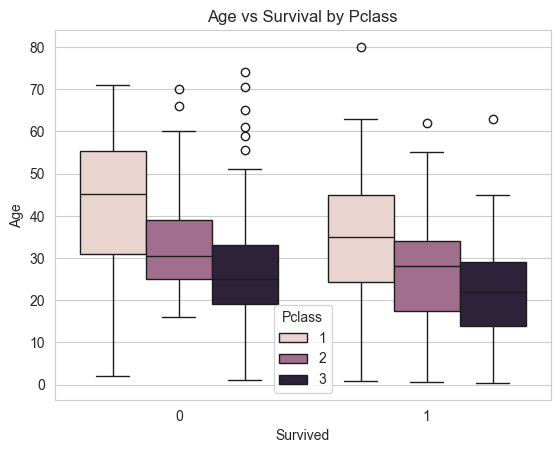

In [17]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', kind='bar', data=df)
plt.title("Survival by Pclass & Sex")
plt.show()

sns.boxplot(x='Survived', y='Age', hue='Pclass', data=df)
plt.title("Age vs Survival by Pclass")
plt.show()


Task 12

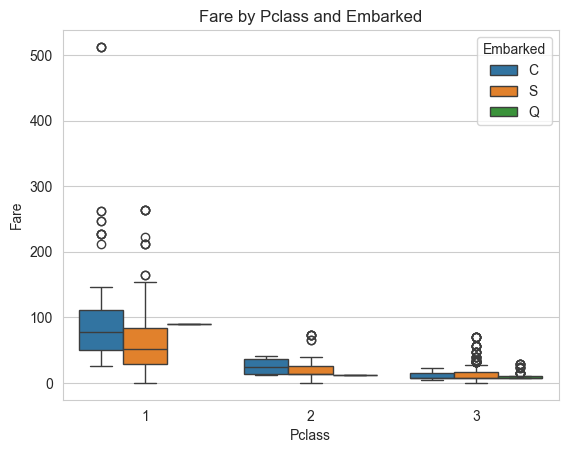

In [19]:
sns.boxplot(x='Pclass', y='Fare', hue='Embarked', data=df)
plt.title("Fare by Pclass and Embarked")
plt.show()


Task 13

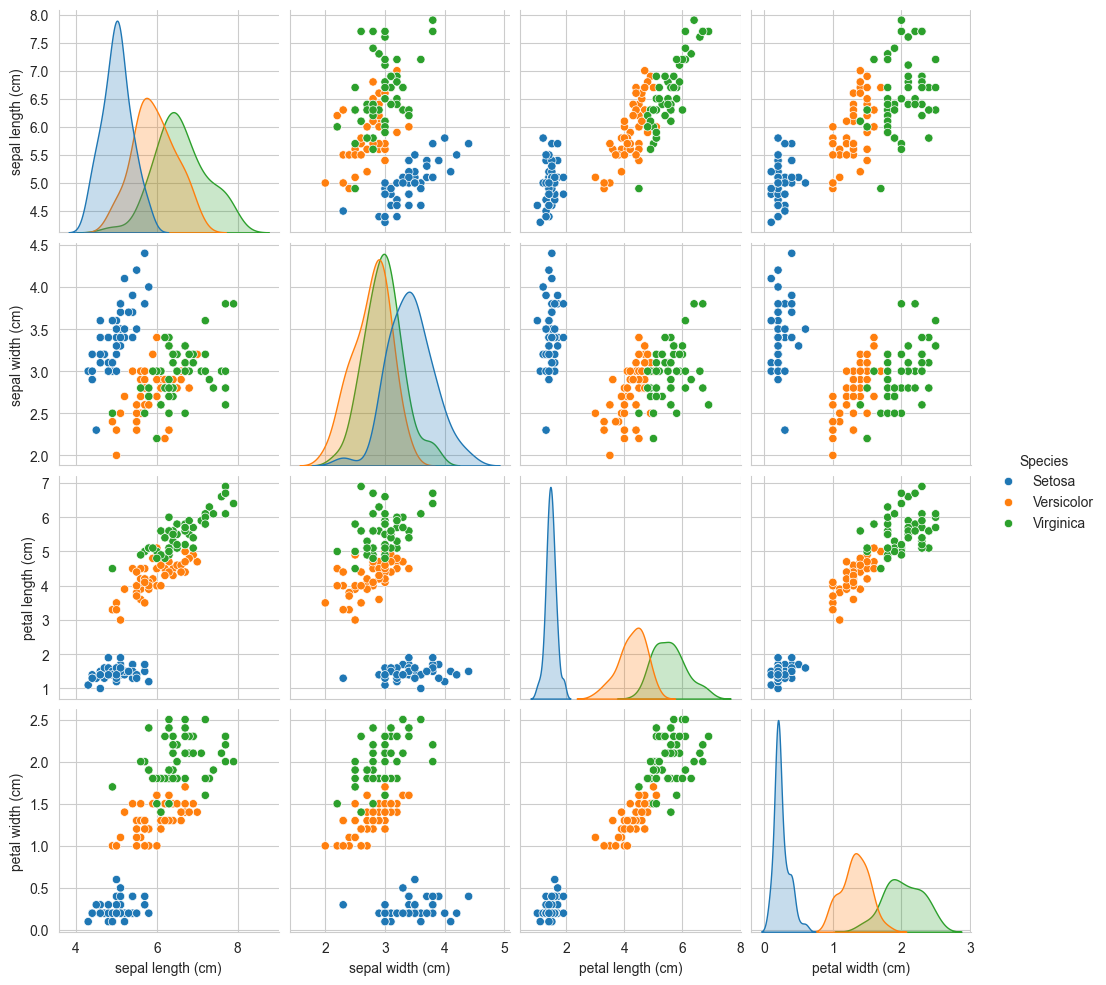

Iris Correlation Matrix:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


In [20]:
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['Species'] = iris.target

# Map numeric species to names
iris_df['Species'] = iris_df['Species'].map(
    {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
)

sns.pairplot(iris_df, hue='Species')
plt.show()

print("Iris Correlation Matrix:")
print(iris_df.drop(columns=['Species']).corr())